In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns # plot corr matrix

import scipy.stats as stats
from scipy.stats import linregress

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# Correlation coefficient
def coor_coef(x, y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    return np.sum((x - x_mean)*(y - y_mean)) / (np.sqrt(np.sum((x - x_mean)**2)) * np.sqrt(np.sum((y - y_mean)**2)))

# RMSE
def clc_rmse(true, pred):
    return np.sqrt(np.mean((true - pred) ** 2))

In [3]:
# df = pd.read_csv("/dmidata/users/zoerem/data/matchup_atmo_surf/filter_mu_atmo_surf_obs2345.csv")
df = pd.read_csv("/Users/zoere/OneDrive/Bureau/cours/STAGE_M2_S10/ordi dmi/data/filter_mu_atmo_surf_obs2345.csv")
# df

In [4]:
promist = df["SurfaceTemperature(C)"]+273.15

obs_error = df["ist_1tdomain"] -promist 
sim_error = df["istsim_1tdomain"]-promist
error_diff = obs_error - sim_error

In [5]:
df["obs_error"] = df["ist_1tdomain"] - df["ist_promice"]
df["sim_error"] = df["istsim_1tdomain"] - df["ist_promice"]
df["error_diff"] = df["obs_error"] - df["sim_error"]

# Understand the data

## Seasonality of the error

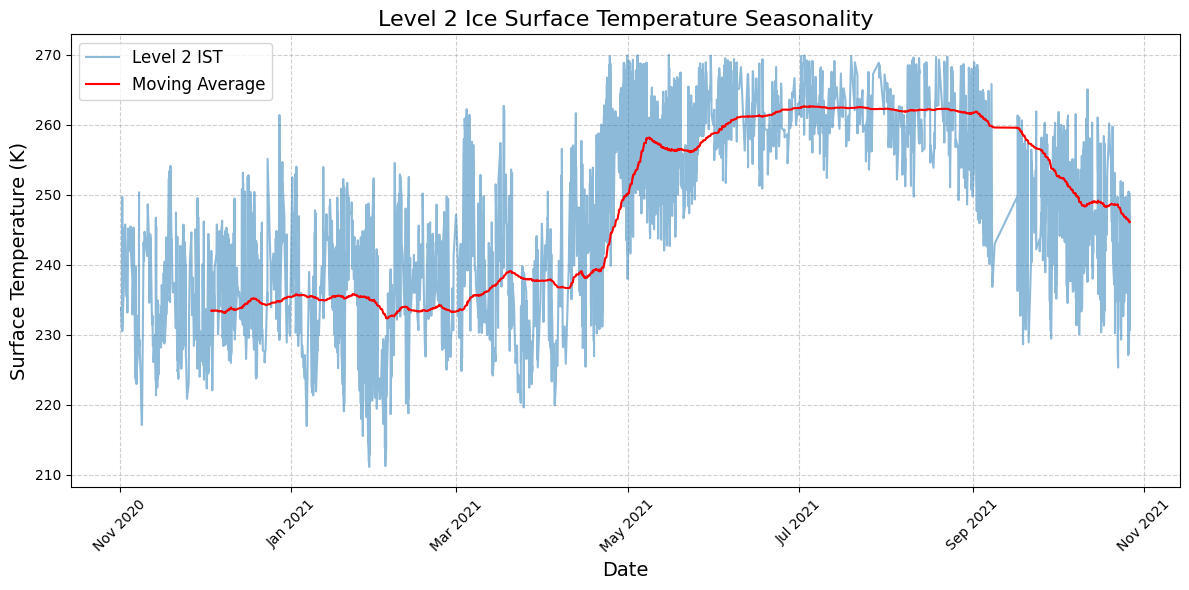

In [13]:
time = pd.to_datetime(df["lev1_obstime"])

window_size = 300
# error_mean = np.convolve(error_diff, np.ones(window_size)/window_size, mode='valid')
# error_mean = np.convolve(obs_error, np.ones(window_size)/window_size, mode='valid')
temp_mean = np.convolve(df["lev2_surface_temperature"], np.ones(window_size)/window_size, mode='valid')



time_mean = time.iloc[window_size - 1:]  # Drop the first (window_size - 1) timestamps

# Plot
plt.figure(figsize=(12, 6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2)) 

# plt.plot(time, error_diff, alpha=0.5, label="Raw error")
# plt.plot(time, obs_error, alpha=0.5, label="Raw error")
plt.plot(time, df["lev2_surface_temperature"], alpha=0.5, label="Level 2 IST")

# plt.plot(time_mean, error_mean, color='red', linewidth=1.5, label="Running mean")
plt.plot(time_mean, temp_mean, color='red', linewidth=1.5, label="Moving Average")


plt.xlabel("Date", fontsize=14)
# plt.ylabel("Error (K)")
plt.ylabel("Surface Temperature (K)", fontsize=14)

# plt.title("AVHRR IST obs minus RTTOV IST simu\nTime series with running mean")
# plt.title("IST AVHRR minus AWS PROMICE obs\nTime series with running mean")
plt.title("Level 2 Ice Surface Temperature Seasonality", fontsize=16)

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
# plt.savefig("/home/zoerem/Documents/STAGE/figures/lev2temp_seasonality.png", dpi=500, transparent=True,  bbox_inches="tight")
plt.show()

# Influential variables (hypotheses)

In [8]:
features = ["lev1_channel4", "lev1_channel5", "lev1_satzenith_angle", # OSISAF obs
           "nwp_t2m", "nwp_d2m", "nwp_tcc", "nwp_skt", "nwp_q2m", # nwp surf
           "rttov_channel4", "rttov_channel5", "rttov_emis_channel4", "rttov_emis_channel5", # rttov
           "AirTemperature(C)", "CloudCover", "ShortwaveRadiationDown(W/m2)", "Albedo_theta<70d", "SpecificHumidity(g/kg)", # promice
            "nwp_t_1000_hPa", "nwp_t_850_hPa", "nwp_t_300_hPa", "nwp_q_1000_hPa", "nwp_q_850_hPa", "nwp_q_300_hPa" # atmo
           ]

features2 = ["error_diff", 
            "CloudCover", "nwp_tcc", # cloud cover
             "lev1_sunzenith_angle", "Albedo_theta<70d", # sun & albedo
             "lev1_channel4", "lev1_channel5",  "rttov_channel4", "rttov_channel5", # channels ≈ surf temp
             # "rttov_emis_channel4", "rttov_emis_channel5", "ShortwaveRadiationDown(W/m2)",
              "nwp_skt", "nwp_d2m", "nwp_t2m", # nwp surf  
           "AirTemperature(C)",  "nwp_t_1000_hPa", "nwp_t_850_hPa", # air / surf temp
              "nwp_q2m", "SpecificHumidity(g/kg)", "nwp_q_1000_hPa", "nwp_q_850_hPa", # air / surf humidity
           ]


# Correlations
using *.corrwith* from panda

In [9]:
error = "error_diff" # or "obs_error" or "sim_error" or error_diff
correlations = df[features].corrwith(df[error]) # or "obs_error" or "sim_error" or error_diff

# # /print
# corr_sort = correlations.sort_values(ascending=False)
# print(corr_sort)
# # print/

# # Plot
# correlations.sort_values().plot(kind='barh', figsize=(8, 10))
# plt.title(f"Linear correlations between features and '{error}'")
# plt.xlabel("Correlations")
# plt.tight_layout()
# # plt.savefig(f"/home/zoerem/Documents/STAGE/figures/corr_{error}.png")
# plt.show()

### Simply plot error_diff VS variables:

In [10]:
# df.plot.scatter("CloudCover", "sim_error", alpha=0.4)
# plt.show()

### Matrice correlations

In [11]:
corrM = df[features2].corr()
# corrM.style.background_gradient(cmap='coolwarm').format(precision=2)

# ONLY ONE CORNER
mask = np.zeros_like(corrM, dtype=bool)
mask[np.triu_indices_from(mask)] = True
corrM[mask] = np.nan

In [12]:
# corrM.style.background_gradient(cmap='coolwarm', axis=None, vmin=-1, vmax=1).highlight_null(color='#f1f1f1').format(precision=2)

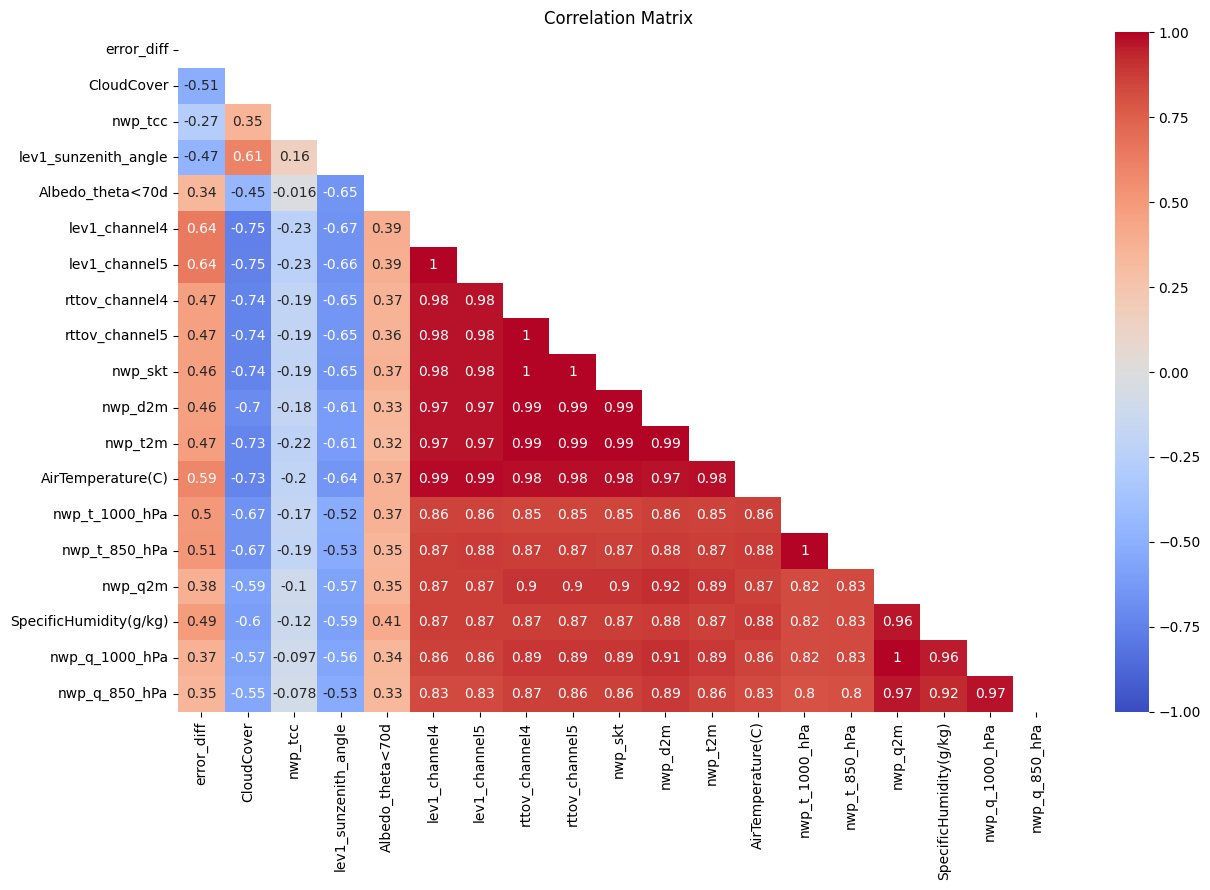

In [13]:
plt.figure(figsize=(13,9))
sns.heatmap(corrM, cmap="coolwarm",annot=True, vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
# plt.savefig("/home/zoerem/Documents/STAGE/figures/corr_matrix.png")
plt.show()

### Sun angle?

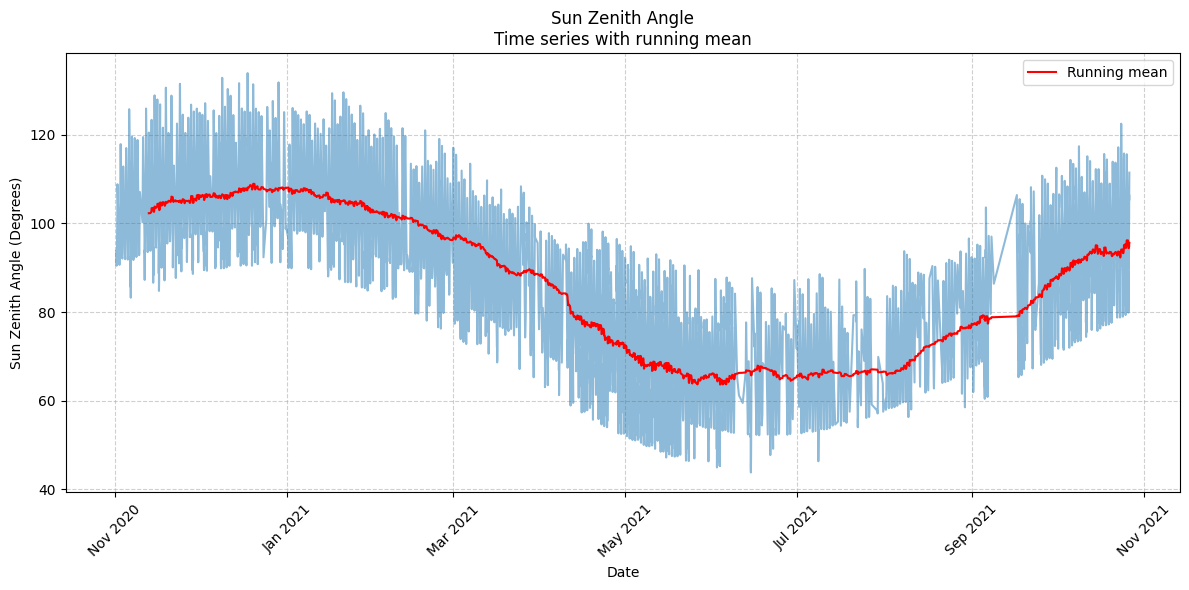

In [14]:
time = pd.to_datetime(df["lev1_obstime"])

window_size = 100
sun_mean = np.convolve(df["lev1_sunzenith_angle"], np.ones(window_size)/window_size, mode='valid')

time_mean = time.iloc[window_size - 1:]  # Drop the first (window_size - 1) timestamps

# Plot
plt.figure(figsize=(12, 6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2)) 

plt.plot(time, df["lev1_sunzenith_angle"], alpha=0.5)
plt.plot(time_mean, sun_mean, color='red', linewidth=1.5, label="Running mean")

plt.xlabel("Date")
plt.ylabel("Sun Zenith Angle (Degrees)")
plt.title("Sun Zenith Angle\nTime series with running mean")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
# plt.savefig("/home/zoerem/Documents/STAGE/figures/sunangle_seasonality.png")
plt.show()

# PCA

In [15]:
X = df[features].dropna()  # Drop rows with NaNs for simplicity
X_scaled = StandardScaler().fit_transform(X)  # normalize the features (zero mean, unit variance) PCA is sensitive to scale.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_pca is the shape of the number of row of df and 3 culumns, because 3 components

[0.65057281 0.08571309]
[0.65057281 0.7362859 ]


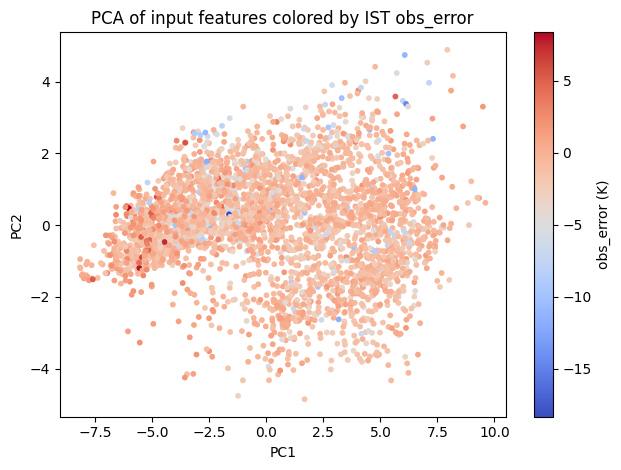

In [16]:
error = "obs_error" # or "obs_error" or "sim_error" or error_diff

# PCA stats
explained_variance_ratio = pca.explained_variance_ratio_
print(explained_variance_ratio)

cumulative_variance = explained_variance_ratio.cumsum()
print(cumulative_variance)


# err_max = 13
# err_min = -12
# cbar_ticks = np.arange(err_min, err_max + 1, 2)


pcaplot = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df.loc[X.index, error], cmap='coolwarm', s=10)#, vmin=err_min, vmax=err_max)
cbar = plt.colorbar(pcaplot)#, ticks=cbar_ticks)
cbar.set_label(f"{error} (K)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"PCA of input features colored by IST {error}")
plt.tight_layout()
# plt.savefig(f"/home/zoerem/Documents/STAGE/figures/PCA_{error}.png")
plt.show()
# plt.scatter(X_pca[:, 1], X_pca[:, 2], c=df.loc[X.index, "error_diff"], cmap='coolwarm', s=10)
# plt.colorbar(label="Observation IST Error")
# plt.xlabel("PC2")
# plt.ylabel("PC3")
# plt.title("PCA of input features colored by IST observation error")
# plt.show()

# plt.scatter(X_pca[:, 0], X_pca[:, 2], c=df.loc[X.index, "error_diff"], cmap='coolwarm', s=10)
# plt.colorbar(label="Observation IST Error")
# plt.xlabel("PC1")
# plt.ylabel("PC3")
# plt.title("PCA of input features colored by IST observation error")
# plt.show()

PC1 is more important with 65%, compare to PC2 with 8.6%.

So lets look at the weights for each variables in PC1: 

In [17]:
loadings = pd.DataFrame(pca.components_, columns=features, index=['PCA1', 'PCA2'])
list_weights = loadings.T[["PCA1"]]

# /print
print(list_weights.sort_values("PCA1", ascending=True))
# print/

# # plot
# list_weights.sort_values("PCA1", ascending=True).plot(kind='barh', figsize=(8, 10))
# plt.title("Contributing features to PC1")
# plt.xlabel("Weights")
# plt.tight_layout()
# # plt.savefig("/home/zoerem/Documents/STAGE/figures/PC1_weights.png")
# plt.show()

                                  PCA1
CloudCover                   -0.194096
rttov_emis_channel5          -0.127001
rttov_emis_channel4          -0.101829
nwp_tcc                      -0.051068
lev1_satzenith_angle         -0.004810
Albedo_theta<70d              0.116652
ShortwaveRadiationDown(W/m2)  0.152725
nwp_q_300_hPa                 0.155360
nwp_t_300_hPa                 0.163648
nwp_t_1000_hPa                0.233079
nwp_q_850_hPa                 0.234101
nwp_t_850_hPa                 0.235746
SpecificHumidity(g/kg)        0.241140
nwp_q_1000_hPa                0.241532
nwp_q2m                       0.243156
AirTemperature(C)             0.249832
nwp_t2m                       0.250205
lev1_channel5                 0.250531
lev1_channel4                 0.250884
nwp_d2m                       0.251901
rttov_channel5                0.252153
rttov_channel4                0.252256
nwp_skt                       0.252260


But since PC1 does not exceed 70-75%, and PC2 still explains almost 9%, it is relevant to also look at PC2 to complete the interpretation.

In [18]:
list_weights2 = loadings.T[["PCA2"]]
print(list_weights2.sort_values("PCA2", ascending=True))

# # plot
# list_weights2.sort_values("PCA2", ascending=True).plot(kind='barh', figsize=(8, 10))
# plt.title("Contributing features to PC2")
# plt.xlabel("Weights")
# plt.tight_layout()
# # plt.savefig("/home/zoerem/Documents/STAGE/figures/PC2_weights.png")
# plt.show()

                                  PCA2
ShortwaveRadiationDown(W/m2) -0.422040
Albedo_theta<70d             -0.416809
lev1_satzenith_angle         -0.097279
lev1_channel4                 0.017899
lev1_channel5                 0.023481
SpecificHumidity(g/kg)        0.030744
AirTemperature(C)             0.037245
nwp_skt                       0.043441
rttov_channel4                0.049514
rttov_channel5                0.049804
nwp_t2m                       0.071217
nwp_q2m                       0.075073
nwp_d2m                       0.080355
nwp_q_1000_hPa                0.089828
nwp_t_1000_hPa                0.098916
nwp_tcc                       0.099792
nwp_t_850_hPa                 0.108327
nwp_t_300_hPa                 0.122774
nwp_q_850_hPa                 0.122803
nwp_q_300_hPa                 0.130698
CloudCover                    0.142209
rttov_emis_channel5           0.460236
rttov_emis_channel4           0.540998


# Cluster PCA with GMM

In [19]:
# new features from previous results
cluster_features = [
    # "error_diff", # idk for this one
    # PC1
    "AirTemperature(C)", "CloudCover", "SpecificHumidity(g/kg)",
    "nwp_d2m", "nwp_t2m", "nwp_skt", "nwp_q2m",
    "nwp_t_1000_hPa", "nwp_q_850_hPa", "nwp_t_850_hPa", "nwp_q_1000_hPa", 
    "lev1_channel4", "lev1_channel5",
    "rttov_channel4", "rttov_channel5",
    # PC2
    "ShortwaveRadiationDown(W/m2)", "Albedo_theta<70d",
    "rttov_emis_channel5", "rttov_emis_channel4"
]

/tmp/ipykernel_202678/545962297.py:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], c=scatter.cmap(0), label="Cluster 0")
/tmp/ipykernel_202678/545962297.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([], [], c=scatter.cmap(9), label="Cluster 1")


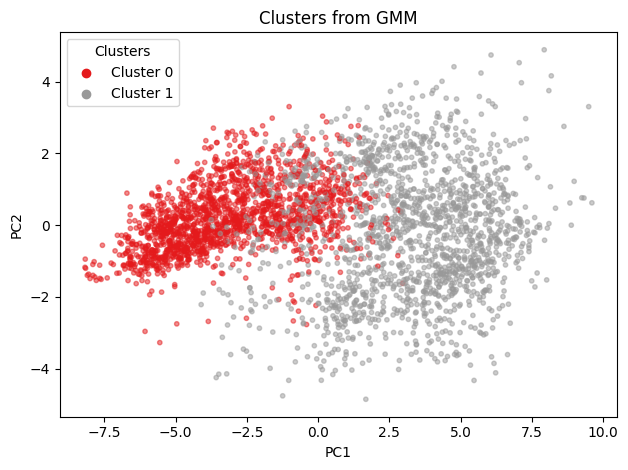

In [20]:
X_clust = df[features].dropna()
X_scaled_clust = StandardScaler().fit_transform(X_clust)

# PCA just for visualization
pca_clust = PCA(n_components=2)
X_pca_clust = pca_clust.fit_transform(X_scaled_clust)

# GMM Clustering
gmm = GaussianMixture(n_components=2, random_state=0)
labels = gmm.fit_predict(X_scaled_clust)

# Plot
scatter = plt.scatter(X_pca_clust[:, 0], X_pca_clust[:, 1], c=labels, alpha=0.5, cmap="Set1", s=10)


plt.scatter([], [], c=scatter.cmap(0), label="Cluster 0")
plt.scatter([], [], c=scatter.cmap(9), label="Cluster 1")
plt.legend(title="Clusters")

plt.title("Clusters from GMM")
plt.xlabel("PC1")
plt.ylabel("PC2")
# plt.colorbar(label="Cluster")

plt.tight_layout()
# plt.savefig("/home/zoerem/Documents/STAGE/figures/PCA_clusters.png")
plt.show()

## Plot each cluster

In [21]:
df_clustered = df.loc[X_clust.index].copy()
df_clustered["cluster"] = labels

indices_c0 = np.where(df_clustered["cluster"] == 0)[0]
indices_c1 = np.where(df_clustered["cluster"] == 1)[0]

ist1_c0 = df_clustered.loc[indices_c0, 'ist_1tdomain']
prom_c0 = df_clustered.loc[indices_c0, 'SurfaceTemperature(C)'] +273.15

ist1_c1 = df_clustered.loc[indices_c1, 'ist_1tdomain']
prom_c1 = df_clustered.loc[indices_c1, 'SurfaceTemperature(C)'] +273.15

In [22]:
# Stats
r_c0 = coor_coef(ist1_c0, prom_c0) *100
rmse_c0 = clc_rmse(ist1_c0, prom_c0) 

r_c1 = coor_coef(ist1_c1, prom_c1)*100
rmse_c1 = clc_rmse(ist1_c1, prom_c1)

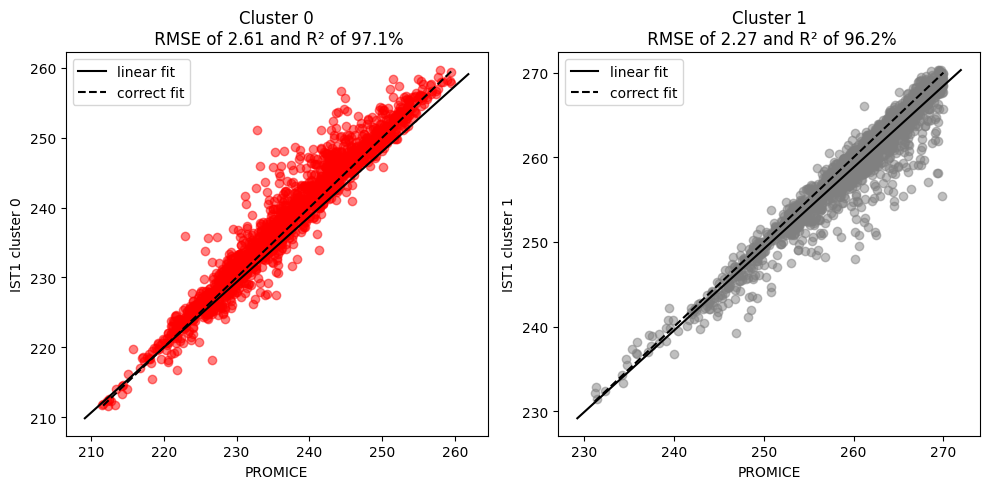

In [23]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.scatter(ist1_c0, prom_c0, alpha=0.5, color='red')

# Fit linear regression
slope, intercept, r_value, p_value, std_err = linregress(prom_c0, ist1_c0)
x_vals = np.array(plt.xlim()) 
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color="k", label='linear fit')
plt.plot([min(prom_c0), max(prom_c0)], [min(prom_c0), max(prom_c0)], 'k--', label='correct fit')

plt.title(f"Cluster 0\n RMSE of {rmse_c0:.2f} and R² of {r_c0:.1f}%") # STD of {y_pred_np.std():.2f},
plt.xlabel("PROMICE")
plt.ylabel("IST1 cluster 0")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(prom_c1, ist1_c1, alpha=0.5, color='gray')

# Fit linear regression
slope, intercept, r_value, p_value, std_err = linregress(prom_c1, ist1_c1)
x_vals = np.array(plt.xlim()) 
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color="k", label='linear fit')
plt.plot([min(prom_c1), max(prom_c1)], [min(prom_c1), max(prom_c1)], 'k--', label='correct fit')

plt.title(f"Cluster 1\n RMSE of {rmse_c1:.2f} and R² of {r_c1:.1f}%") # STD of {y_pred_np.std():.2f},
plt.xlabel("PROMICE")
plt.ylabel("IST1 cluster 1")
plt.legend()

plt.tight_layout()
# plt.savefig("/home/zoerem/Documents/STAGE/figures/PCA_scatter_clusters.png")
plt.show()

# Skewness and Kurtosis

Skewness : 0.35265821281062437
Kurtosis : 3.107934292579397


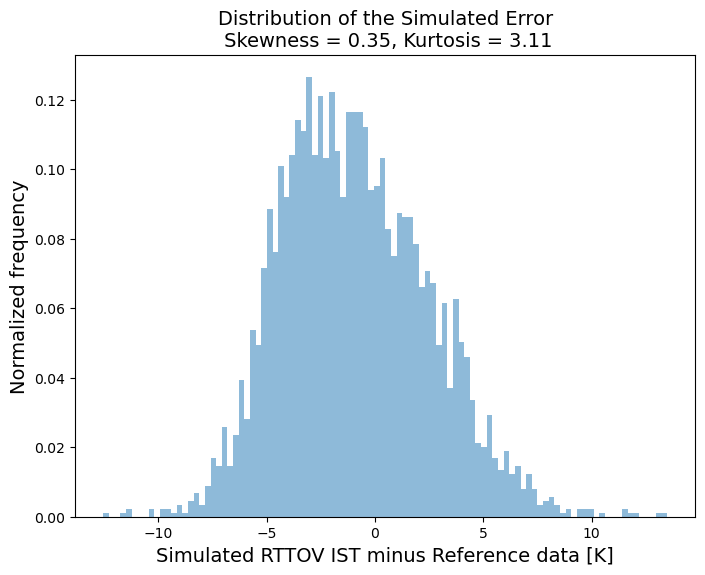

In [16]:
from scipy.stats import skew, kurtosis

## Diff tests


#data2plot=(ist3c_l2).to_numpy() # ist3c_l2=ds["lev2_surface_temperature"]-promist # direct output of OSI SAF 

#data2plot=(sim3c).to_numpy() # sim3c=ds["istsim_3tdomain"]-promist
data2plot = (df["istsim_3tdomain"] - df["ist_promice"]).to_numpy()

# Skewness
skewness_val = skew(data2plot, bias=False)

# Kurtosis (excess kurtosis par défaut → ajouter fisher=False pour valeur "classique")
kurtosis_val = kurtosis(data2plot, bias=False, fisher=False)

print("Skewness :", skewness_val)
print("Kurtosis :", kurtosis_val)


plt.figure(figsize=(8, 6))
plt.hist(data2plot, bins=100, histtype='bar', density=True,  alpha=0.5)
#plt.title(f"Distribution of the Observed Error\n Skewness = {skewness_val:.2f}, Kurtosis = {kurtosis_val:.2f}", fontsize=14) 
plt.title(f"Distribution of the Simulated Error\n Skewness = {skewness_val:.2f}, Kurtosis = {kurtosis_val:.2f}", fontsize=14) 


plt.ylabel("Normalized frequency", fontsize=14)
#plt.xlabel("Operational level 2 minus Reference data [K]", fontsize=14)
plt.xlabel("Simulated RTTOV IST minus Reference data [K]", fontsize=14)
#plt.savefig("/home/zoerem/Documents/STAGE/figures/distribution_obserror.png", dpi=500, transparent=True)
#plt.savefig("/home/zoerem/Documents/STAGE/figures/distribution_simerror.png", dpi=500, transparent=True)




plt.show()

# GMM

In [13]:
# data2plot=(error_diff).to_numpy()
# data2plot = (df["ist_1tdomain"]-df["istsim_1tdomain"]).to_numpy()
# data2plot = (df["ist_1tdomain"] - df["ist_promice"]).to_numpy()
# data2plot = (df["istsim_3tdomain"] - df["ist_promice"]).to_numpy()
data2plot = (df["lev2_surface_temperature"]-promist).to_numpy()

fgmm = np.ravel(data2plot).astype(np.float64) 
fgmm = fgmm.reshape(-1,1) 
N = 2 # n_components
g = GaussianMixture(N,covariance_type='full')
g.fit(fgmm) 

labels = g.predict(fgmm)  # array of 0s and 1s
probas = g.predict_proba(fgmm)

weights = g.weights_ 
means = g.means_ 
covars = g.covariances_ 
stds = [ np.sqrt( np.trace(covars[i])/N) for i in range(0,N) ]
# You can get variance in the diagonal of the covariance matrix: first diagonal element is sigma_x and second is sigma_y.
# will give you the mean std deviation of each mixture

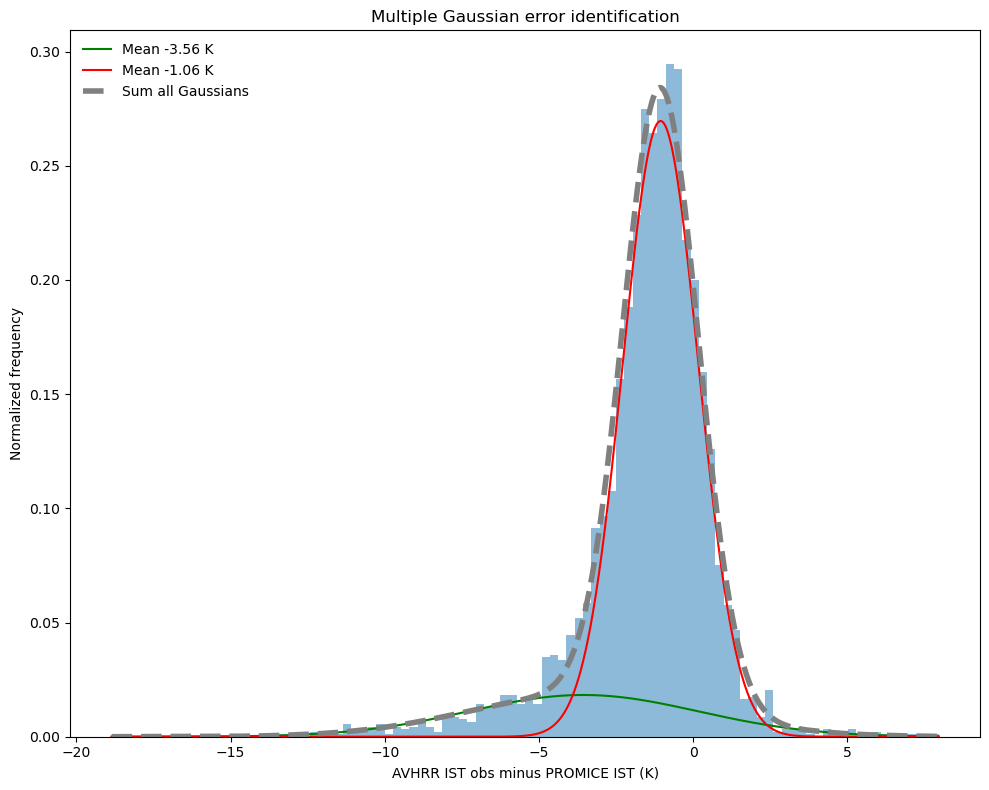

In [14]:
# PLOT 'poster'
plt.figure(figsize=(10, 8))

plt.hist(fgmm, bins=100, histtype='bar', density=True,  alpha=0.5)


f_axis = fgmm.copy().ravel()
f_axis.sort()

plt.title("Multiple Gaussian error identification")
plt.ylabel("Normalized frequency")
# plt.xlabel("AVHRR IST obs minus RTTOV IST sim (K)")
plt.xlabel("AVHRR IST obs minus PROMICE IST (K)")
# plt.xlabel("RTTOV IST sim minus PROMICE IST (K)")


text_kwargs = dict(ha='center', va='center', fontsize=10, color='grey')
label0= "Mean " + str(round(means[0][0],2)) + " K"
label1= "Mean " + str(round(means[1][0],2)) + " K"

# plt.text(2.0, 0.05, 'Valid data', rotation=90, **text_kwargs)
# plt.text(-3.9, 0.03, 'Atmospheric issues', rotation=70, **text_kwargs)
plt.plot(f_axis,weights[0]*stats.norm.pdf(f_axis,means[0],np.sqrt(covars[0])).ravel(), c='green',  label=label0)
plt.plot(f_axis,weights[1]*stats.norm.pdf(f_axis,means[1],np.sqrt(covars[1])).ravel(), c='red', label=label1)

plt.plot(f_axis,+weights[1]*stats.norm.pdf(f_axis,means[1],np.sqrt(covars[1])).ravel()
         +weights[0]*stats.norm.pdf(f_axis,means[0],np.sqrt(covars[0])).ravel(), 
         c='grey', linewidth=4, linestyle="--", label="Sum all Gaussians")
plt.legend(loc="upper left",facecolor="None", edgecolor="None")

plt.tight_layout()
# plt.savefig("/home/zoerem/Documents/STAGE/figures/poster_gauss_filtered.png")
# plt.savefig("/home/zoerem/Documents/STAGE/figures/hist_rttov_prom.png", dpi=300, transparent=True)
plt.show()

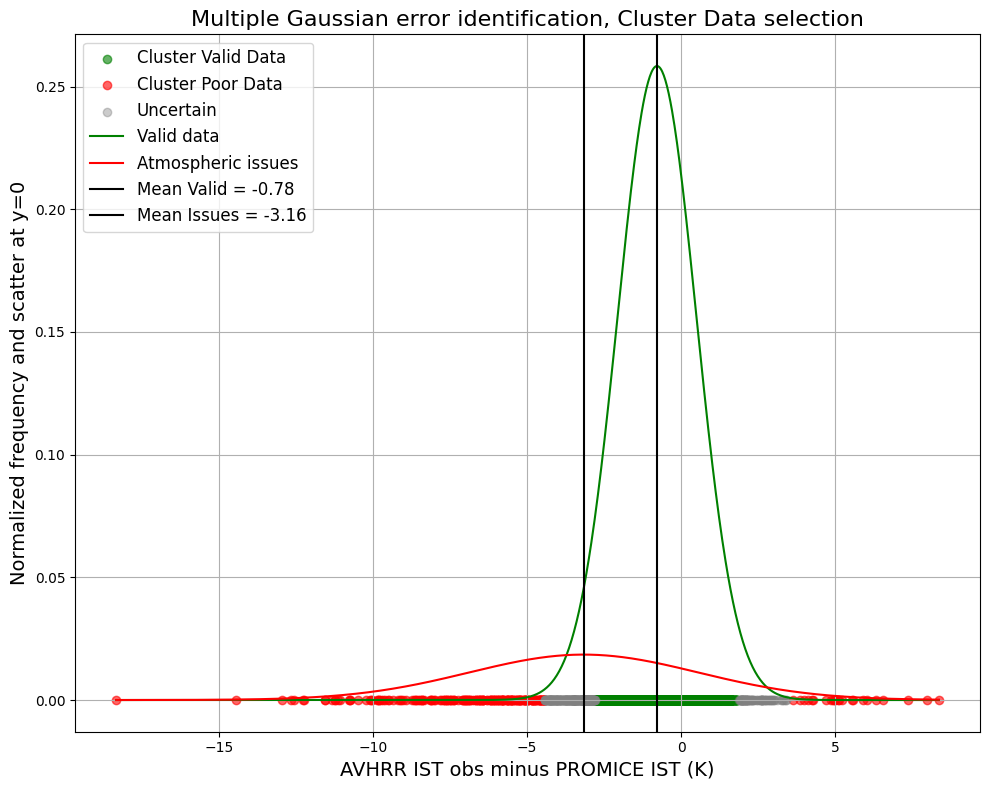

In [26]:
# Define masks
threshold0 = 0.8
threshold1 = 0.8
mask_cluster_0 = (probas[:, 0] > threshold0) & (probas[:, 1] < (1 - threshold0))
mask_cluster_1 = (probas[:, 1] > threshold1) & (probas[:, 0] < (1 - threshold1))


# mask_cluster_0 = (fgmm[:, 0] >= means[0][0] - stds[0]) & (fgmm[:, 0] <= means[0][0] + 2*stds[0])
# mask_cluster_1 = (fgmm[:, 0] >= means[1][0] - 2*stds[1]) & (fgmm[:, 0] <= means[1][0] + stds[1])

mask_uncertain = ~(mask_cluster_0 | mask_cluster_1)

plt.figure(figsize=(10, 8))

# plt.hist(fgmm, bins=100, histtype='bar', density=True,  alpha=0.5)



# Plot confident points from cluster 0
plt.scatter(fgmm[mask_cluster_0], np.zeros_like(fgmm[mask_cluster_0]), color='green', label="Cluster Valid Data", alpha=0.6)

# Plot confident points from cluster 1
plt.scatter(fgmm[mask_cluster_1], np.zeros_like(fgmm[mask_cluster_1]), color='red', label="Cluster Poor Data", alpha=0.6)

# Plot uncertain points
plt.scatter(fgmm[mask_uncertain], np.zeros_like(fgmm[mask_uncertain]), color='gray', label='Uncertain', alpha=0.4)

# plot Gaussian
x_vals = np.linspace(fgmm.min(), fgmm.max(), 1000).reshape(-1, 1)
logprob = g.score_samples(x_vals)
responsibilities = g.predict_proba(x_vals)
pdf = np.exp(logprob)
pdf_individual = responsibilities * pdf[:, np.newaxis]


plt.plot(x_vals, pdf_individual[:, 0], color='green', label="Valid data")
plt.plot(x_vals, pdf_individual[:, 1], color='red', label="Atmospheric issues")


# # # Mean STD cluster 0
plt.axvline(means[0][0],color='k',label=f'Mean Valid = {means[0][0]:.2f}')
# plt.axvline(means[0][0] + stds[0],color='blue',linestyle='--',label='Mean + 1std')
# plt.axvline(means[0][0] - stds[0],color='blue',linestyle='--',label='Mean - 1std')
# # # Mean STD cluster 1
plt.axvline(means[1][0],color='k',label=f'Mean Issues = {means[1][0]:.2f}')
# plt.axvline(means[1][0] + stds[1],color='red',linestyle='--',label='Mean + 1std')
# plt.axvline(means[1][0] - stds[1],color='red',linestyle='--',label='Mean - 1std')

# plt.title(f"GMM Clustering with Confidence Threshold={threshold}")
plt.title(f"Multiple Gaussian error identification, Cluster Data selection", fontsize=16 )
# plt.xlabel("AVHRR IST obs minus RTTOV IST (K)")
plt.xlabel("AVHRR IST obs minus PROMICE IST (K)", fontsize=14)
plt.ylabel("Normalized frequency and scatter at y=0", fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True)
plt.tight_layout()
# plt.savefig("/home/zoerem/Documents/STAGE/figures/GMM_boplot_1std.png")
# plt.savefig("/home/zoerem/Documents/STAGE/figures/hist_sat_prom_clust.png", dpi=300, transparent=True)
# plt.savefig("/home/zoerem/Documents/STAGE/figures/hist_sat_prom_clust.png", dpi=500, transparent=True)
plt.show()

## Plot each cluster

In [27]:
# threshold0 = 0.9
# threshold1 = 0.4
indices_cluster_0 = np.where((probas[:, 0] > threshold0) & (probas[:, 1] < (1 - threshold0)))[0]
indices_cluster_1 = np.where((probas[:, 1] > threshold1) & (probas[:, 0] < (1 - threshold1)))[0]
# indices_cluster_0 = np.where((fgmm[:, 0] >= means[0][0] - stds[0]) & (fgmm[:, 0] <= means[0][0] + 2*stds[0]))[0]
# indices_cluster_1 = np.where((fgmm[:, 0] >= means[1][0] - 2*stds[1]) & (fgmm[:, 0] <= means[1][0] + stds[1]))[0]


# n data point from each cluster:
print("len 0 = ",len(indices_cluster_0))
print("len 1 = ",len(indices_cluster_1))

# ist1_gmm0 = df.loc[indices_cluster_0, 'ist_1tdomain']
ist1_gmm0 = df.loc[indices_cluster_0, 'lev2_surface_temperature']

prom_gmm0 = df.loc[indices_cluster_0, 'SurfaceTemperature(C)'] +273.15

cc_gmm0 = df.loc[indices_cluster_0, 'CloudCover']
suna_gmm0 = df.loc[indices_cluster_0, 'lev1_sunzenith_angle']
tcw_gmm0 = df.loc[indices_cluster_0, 'nwp_tcw']


# ist1_gmm1 = df.loc[indices_cluster_1, 'ist_1tdomain']
ist1_gmm1 = df.loc[indices_cluster_1, 'lev2_surface_temperature']

prom_gmm1 = df.loc[indices_cluster_1, 'SurfaceTemperature(C)'] +273.15

cc_gmm1 = df.loc[indices_cluster_1, 'CloudCover']
suna_gmm1 = df.loc[indices_cluster_1, 'lev1_sunzenith_angle']
tcw_gmm1 = df.loc[indices_cluster_1, 'nwp_tcw']

len 0 =  2810
len 1 =  238


In [28]:
# Stats
r_gmm0 = coor_coef(ist1_gmm0, prom_gmm0) *100
rmse_gmm0 = clc_rmse(ist1_gmm0, prom_gmm0) 

r_gmm1 = coor_coef(ist1_gmm1, prom_gmm1)*100
rmse_gmm1 = clc_rmse(ist1_gmm1, prom_gmm1)

std_residuals_gmm0 = np.std(ist1_gmm0 - prom_gmm0)
std_residuals_gmm1 = np.std(ist1_gmm1 - prom_gmm1)

diff_pist0 = ist1_gmm0 - prom_gmm0
diff_pist1 = ist1_gmm1 - prom_gmm1

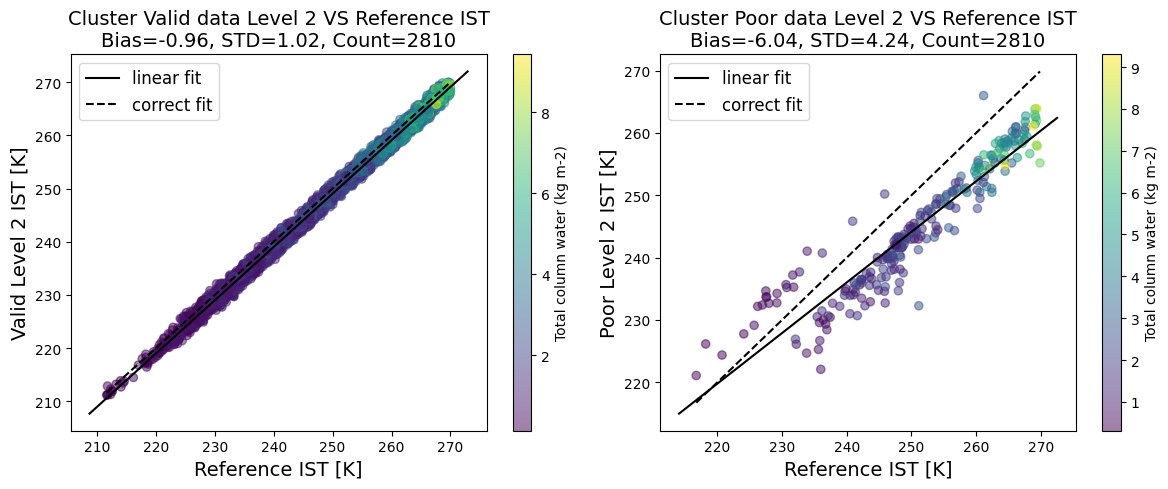

In [41]:
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)

## Colorbar SIMPLE
# plt.scatter(prom_gmm0, ist1_gmm0, alpha=0.5, c='green')

# Colorbar CLOUD COVER
# sc = plt.scatter(prom_gmm0, ist1_gmm0, alpha=0.5, c=cc_gmm0) 
# cbar = plt.colorbar(sc)
# cbar.set_label("CloudCover", rotation=90)

# ## Colorbar Total column water
sc = plt.scatter(prom_gmm0, ist1_gmm0, alpha=0.5, c=tcw_gmm0) 
cbar = plt.colorbar(sc)
cbar.set_label("Total column water (kg m-2)", rotation=90)

## Colorbar SUN ANGLE
# sa_max = 140
# sa_min = 40
# cbar_ticks = np.arange(sa_min, sa_max + 1, 10)
# sc = plt.scatter(prom_gmm0, ist1_gmm0, alpha=0.5, c=suna_gmm0, vmin=sa_min, vmax=sa_max) 
# cbar = plt.colorbar(sc, ticks=cbar_ticks)
# cbar.set_label("Sun Angle", rotation=90)


# Fit linear regression
slope, intercept, r_value, p_value, std_err = linregress(prom_gmm0, ist1_gmm0)
x_vals = np.array(plt.xlim()) 
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color="k", label='linear fit')
plt.plot([min(prom_gmm0), max(prom_gmm0)], [min(prom_gmm0), max(prom_gmm0)], 'k--', label='correct fit')

# plt.title(f"Cluster Issues ({len(indices_cluster_0)} Data)\nBias: {diff_pist0.mean():.2f}, STD: {std_residuals_gmm0:.2f} and R² of {r_gmm0:.1f}%") # with Confidence Threshold={threshold}  , RMSE of {rmse_gmm0:.2f}
plt.title(f"Cluster Valid data Level 2 VS Reference IST\nBias={np.mean(diff_pist0):.2f}, STD={np.std(diff_pist0):.2f}, Count={len(indices_cluster_0)}", fontsize=14)
plt.ylabel("Valid Level 2 IST [K]", fontsize = 14)
plt.xlabel("Reference IST [K]", fontsize = 14)
plt.legend(fontsize = 12)
# plt.grid()

plt.subplot(1, 2, 2)

## Colorbar SIMPLE
# plt.scatter(prom_gmm1, ist1_gmm1, alpha=0.5, color='red')

## Colorbar CLOUD COVER
# sc = plt.scatter(prom_gmm1, ist1_gmm1, alpha=0.5, c=cc_gmm1) 
# cbar = plt.colorbar(sc)
# cbar.set_label("CloudCover", rotation=90)

## Colorbar Total column water
sc = plt.scatter(prom_gmm1, ist1_gmm1, alpha=0.5, c=tcw_gmm1) 
cbar = plt.colorbar(sc)
cbar.set_label("Total column water (kg m-2)", rotation=90)

## Colorbar SUN ANGLE
# sa_max = 140
# sa_min = 40
# cbar_ticks = np.arange(sa_min, sa_max + 1, 10)
# sc = plt.scatter(prom_gmm1, ist1_gmm1, alpha=0.5, c=suna_gmm1, vmin=sa_min, vmax=sa_max) 
# cbar = plt.colorbar(sc, ticks=cbar_ticks)
# cbar.set_label("Sun Angle", rotation=90)


# Fit linear regression
slope, intercept, r_value, p_value, std_err = linregress(prom_gmm1, ist1_gmm1)
x_vals = np.array(plt.xlim()) 
y_vals = intercept + slope * x_vals
plt.plot(x_vals, y_vals, color="k", label='linear fit')
plt.plot([min(prom_gmm1), max(prom_gmm1)], [min(prom_gmm1), max(prom_gmm1)], 'k--', label='correct fit')

# plt.title(f"Cluster 1 ({len(indices_cluster_1)} Data)\nBias: {diff_pist1.mean():.2f}, STD: {std_residuals_gmm1:.2f} and R² of {r_gmm1:.1f}%") #with Confidence Threshold={threshold}   , RMSE of {rmse_gmm1:.2f} 
plt.title(f"Cluster Poor data Level 2 VS Reference IST\nBias={np.mean(diff_pist1):.2f}, STD={np.std(diff_pist1):.2f}, Count={len(indices_cluster_0)}", fontsize=14)
plt.ylabel("Poor Level 2 IST [K]", fontsize = 14)
plt.xlabel("Reference IST [K]", fontsize = 14)
# plt.ylabel("IST1 Cluster 1")
plt.legend(fontsize = 12)
# plt.grid()

plt.tight_layout()
# plt.savefig("/home/zoerem/Documents/STAGE/figures/scatters_on_clusters_1stdsuna.png")
# plt.savefig("/home/zoerem/Documents/STAGE/figures/Clust_sat_prom.png", dpi=300, transparent=True)
# plt.savefig("/home/zoerem/Documents/STAGE/figures/Clust_sat_prom_tcw.png", dpi=500, transparent=True)
plt.show()

In [42]:
# Define seasons
def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:  # 9, 10, 11
        return "Autumn"


#  Map months to seasons
df["Season"] = df["MonthOfYear"].apply(month_to_season)
seasons = ["Winter", "Spring", "Summer", "Autumn"]

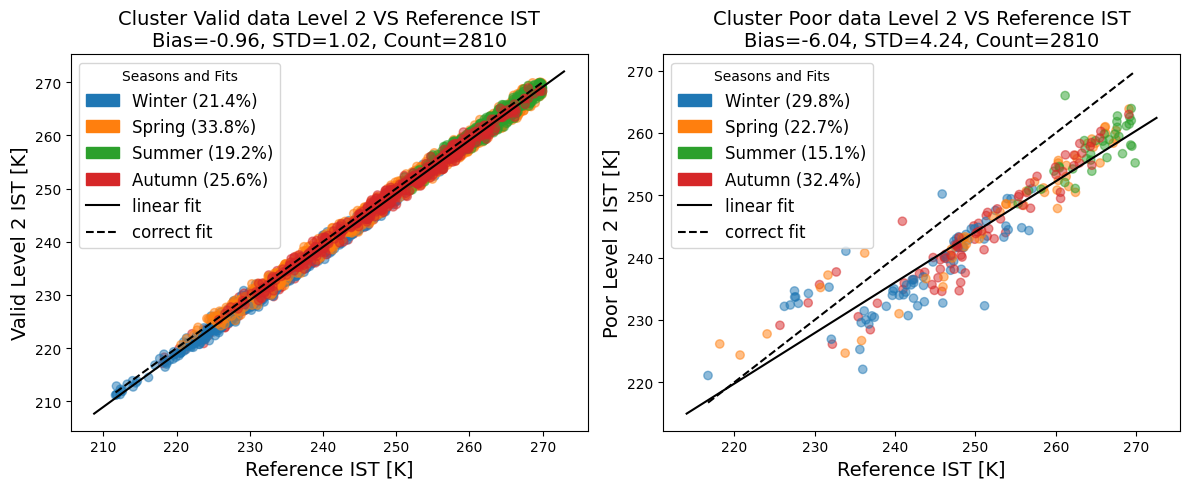

In [50]:


plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)

## QUALITY LEVELS
# desired_order = [2, 3, 4, 5]
# QLVs = [qlv for qlv in desired_order if qlv in df.loc[indices_cluster_0,"lev2_quality_level"].unique()]
# # QLVs = df.loc[indices_cluster_0,"lev2_quality_level"].unique()

# cmap = plt.get_cmap('tab10')
# colors = [cmap(i % 10) for i in range(len(QLVs))] 
# qlv_to_color = {qlv: color for qlv, color in zip(QLVs, colors)}
# point_colors = df.loc[indices_cluster_0,"lev2_quality_level"].map(qlv_to_color)

# sc = plt.scatter(prom_gmm0, ist1_gmm0, alpha=0.5, c=point_colors)

# qlv_counts = df.loc[indices_cluster_0, "lev2_quality_level"].value_counts(normalize=True) * 100
# handles_qlv = [mpatches.Patch(color=qlv_to_color[qlv], label=f"{qlv} ({qlv_counts[qlv]:.1f}%)") for qlv in QLVs]

## SEASONS
season_series = df.loc[indices_cluster_0, "Season"].reset_index(drop=True)
season_counts = season_series.value_counts()
total = season_counts.sum()
season_percentages = {season: f"{(count / total) * 100:.1f}%" for season, count in season_counts.items()}

cmap = plt.get_cmap("tab10")
season_colors = {season: cmap(i) for i, season in enumerate(seasons)}
point_colors = season_series.map(season_colors)

sc = plt.scatter(prom_gmm0, ist1_gmm0, alpha=0.5, c=point_colors)
handles_season = [mpatches.Patch(color=season_colors[season], 
                                label=f"{season} ({season_percentages.get(season, '0.0%')})") for season in seasons]

# Fit linear regression
slope, intercept, r_value, p_value, std_err = linregress(prom_gmm0, ist1_gmm0)
x_vals = np.array(plt.xlim()) 
y_vals = intercept + slope * x_vals
fit1, = plt.plot(x_vals, y_vals, color="k", label='linear fit')
fit2, = plt.plot([min(prom_gmm0), max(prom_gmm0)], [min(prom_gmm0), max(prom_gmm0)], 'k--', label='correct fit')

# plt.title(f"Cluster 0 ({len(indices_cluster_0)} Data)\nBias: {diff_pist0.mean():.2f}, STD: {std_residuals_gmm0:.2f} and R² of {r_gmm0:.1f}%")
# plt.xlabel("PROMICE")
# plt.ylabel("IST1 cluster 0")

plt.title(f"Cluster Valid data Level 2 VS Reference IST\nBias={np.mean(diff_pist0):.2f}, STD={np.std(diff_pist0):.2f}, Count={len(indices_cluster_0)}", fontsize=14)
plt.ylabel("Valid Level 2 IST [K]", fontsize = 14)
plt.xlabel("Reference IST [K]", fontsize = 14)

# handles_all = handles_qlv + [fit1, fit2]
# plt.legend(handles=handles_all, title="Quality Levels and Fits", loc='upper left',fontsize = 12)

handles_all = handles_season + [fit1, fit2]
plt.legend(handles=handles_all, title="Seasons and Fits", loc='upper left',fontsize = 12)



plt.subplot(1, 2, 2)

## QUALITY LEVELS
# desired_order = [2, 3, 4, 5]
# QLVs = [qlv for qlv in desired_order if qlv in df.loc[indices_cluster_1,"lev2_quality_level"].unique()]
# # QLVs = df.loc[indices_cluster_1,"lev2_quality_level"].unique()

# cmap = plt.get_cmap('tab10')
# colors = [cmap(i % 10) for i in range(len(QLVs))] 
# qlv_to_color = {qlv: color for qlv, color in zip(QLVs, colors)}
# point_colors = df.loc[indices_cluster_1,"lev2_quality_level"].map(qlv_to_color)

# sc = plt.scatter(prom_gmm1, ist1_gmm1, alpha=0.5, c=point_colors)

# qlv_counts = df.loc[indices_cluster_1, "lev2_quality_level"].value_counts(normalize=True) * 100
# handles_qlv = [mpatches.Patch(color=qlv_to_color[qlv], label=f"{qlv} ({qlv_counts[qlv]:.1f}%)") for qlv in QLVs]

## SEASONS
season_series = df.loc[indices_cluster_1, "Season"].reset_index(drop=True)
season_counts = season_series.value_counts()
total = season_counts.sum()
season_percentages = {season: f"{(count / total) * 100:.1f}%" for season, count in season_counts.items()}

cmap = plt.get_cmap("tab10")
season_colors = {season: cmap(i) for i, season in enumerate(seasons)}
point_colors = season_series.map(season_colors)

sc = plt.scatter(prom_gmm1, ist1_gmm1, alpha=0.5, c=point_colors)
handles_season = [mpatches.Patch(color=season_colors[season], 
label=f"{season} ({season_percentages.get(season, '0.0%')})") for season in seasons]


# Fit linear regression
slope, intercept, r_value, p_value, std_err = linregress(prom_gmm1, ist1_gmm1)
x_vals = np.array(plt.xlim()) 
y_vals = intercept + slope * x_vals
fit1, = plt.plot(x_vals, y_vals, color="k", label='linear fit')
fit2, = plt.plot([min(prom_gmm1), max(prom_gmm1)], [min(prom_gmm1), max(prom_gmm1)], 'k--', label='correct fit')

plt.title(f"Cluster Poor data Level 2 VS Reference IST\nBias={np.mean(diff_pist1):.2f}, STD={np.std(diff_pist1):.2f}, Count={len(indices_cluster_0)}", fontsize=14)
plt.ylabel("Poor Level 2 IST [K]", fontsize = 14)
plt.xlabel("Reference IST [K]", fontsize = 14)

# handles_all = handles_qlv + [fit1, fit2]
# plt.legend(handles=handles_all, title="Quality Levels and Fits", loc='upper left', fontsize = 12)

handles_all = handles_season + [fit1, fit2]
plt.legend(handles=handles_all, title="Seasons and Fits", loc='upper left', fontsize = 12)


plt.tight_layout()
# plt.savefig("/home/zoerem/Documents/STAGE/figures/scatters_on_clusters_1stdqlvs.png")
# plt.savefig("/home/zoerem/Documents/STAGE/figures/Clust_sat_prom_sason.png", dpi=500, transparent=True)

plt.show()

## Select points in each clusters to plot the atmo profils

In [24]:
dates_cluster_0 = df.loc[indices_cluster_0, "lev1_obstime"]
stations_cluster_0 = df.loc[indices_cluster_0, "station_id"]

dates_cluster_1 = df.loc[indices_cluster_1, "lev1_obstime"]
stations_cluster_1 = df.loc[indices_cluster_1, "station_id"]

start0 = 1135
end0 = 1145

start1 = 255
end1 = 265

subset_0 = pd.DataFrame({
    "Date": dates_cluster_0.iloc[start0:end0].values,
    "Station": stations_cluster_0.iloc[start0:end0].values,
    "IST1": ist1_gmm0.iloc[start0:end0].values,
    "PROMICE": prom_gmm0.iloc[start0:end0].values
})

subset_1 = pd.DataFrame({
    "Date": dates_cluster_1.iloc[start1:end1].values,
    "Station": stations_cluster_1.iloc[start1:end1].values,
    "IST1": ist1_gmm1.iloc[start1:end1].values,
    "PROMICE": prom_gmm1.iloc[start1:end1].values
})

print("\n--- Cluster 0 ---")
print(subset_0)

print("\n--- Cluster 1 ---")
print(subset_1)


--- Cluster 0 ---
                  Date Station        IST1  PROMICE
0  2021-08-24 17:37:00     EGP  262.548514   262.27
1  2021-08-24 17:37:00   KPC_U  268.084413   268.24
2  2021-08-24 19:16:00   KPC_U  267.555515   267.41
3  2021-08-25 12:16:00     EGP  264.779979   265.59
4  2021-08-25 13:55:00     EGP  264.651001   265.50
5  2021-08-25 15:37:00     EGP  264.798719   264.92
6  2021-08-25 17:16:00     EGP  263.584105   264.31
7  2021-08-25 18:55:00     EGP  262.159686   261.88
8  2021-08-25 20:34:00     EGP  259.690993   259.91
9  2021-08-25 23:58:00     EGP  258.035936   256.50

--- Cluster 1 ---
                  Date Station        IST1  PROMICE
0  2020-12-16 00:31:00     EGP  226.804436   230.06
1  2020-12-16 12:28:00     EGP  231.370897   233.08
2  2020-12-17 00:10:00     EGP  230.521181   235.78
3  2020-12-17 12:10:00   KAN_U  250.318114   251.86
4  2020-12-17 15:31:00   KAN_U  249.523730   250.07
5  2020-12-17 22:07:00   KAN_U  247.635153   249.13
6  2020-12-17 23:46:00   K